### Phase 1: Introduction

# Portfolio Project Walkthrough (Kaggle Titanic)

## Objective
Build a machine learning model to predict whether a passenger survived the Titanic disaster.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

### Phase 2: Import Libraries

In [66]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

### Phase 3: Load Dataset

In [67]:
# Load Titanic dataset

df = pd.read_csv("../data/Titanic-Dataset.csv")

# Display first rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Phase 4: Exploratory Data Analysis (EDA)

In [68]:
# Dataset information

df.info()

# Statistical summary

df.describe()

# Missing values

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Create graphs:

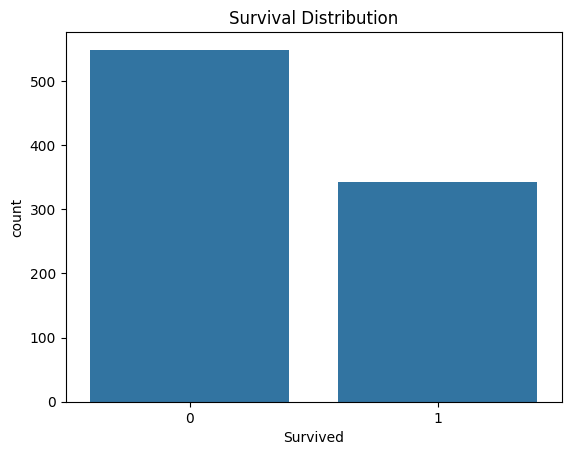

In [69]:
# Survival distribution

sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.savefig("../images/survival_distribution.png")
plt.show()

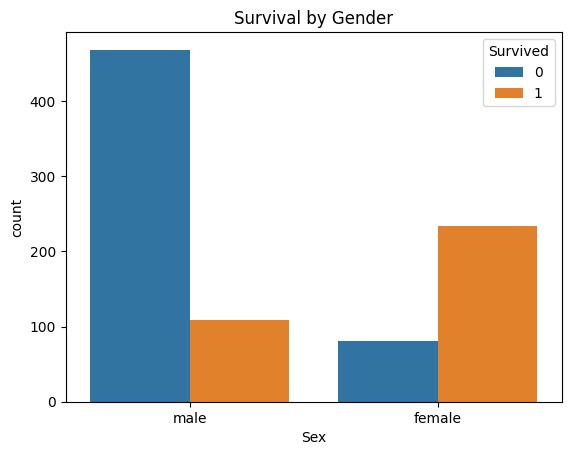

In [70]:
# Survival by gender

sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.savefig("../images/survival_by_gender.png")
plt.show()

### Phase 5: Data Cleaning

In [71]:
# Fill missing Age values

df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill Embarked values

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin

df.drop(columns=["Cabin"], inplace=True)

### Phase 6: Feature Engineering

In [72]:
# Convert categorical values to numbers

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

### Phase 7: Model Building

In [73]:
# Features and target

X = df[[
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Embarked"
]]

y = df["Survived"]

# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
# Train model

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Phase 8: Prediction

In [75]:
# Predict

y_pred = model.predict(X_test)

### Phase 9: Model Evaluation

In [76]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8156424581005587


In [77]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



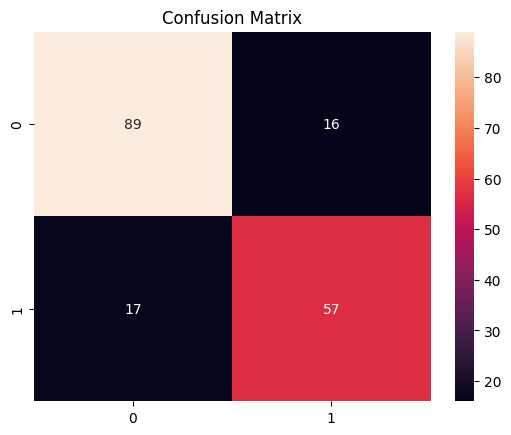

In [79]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.savefig("../images/confusion_matrix.png")
plt.savefig("../images/correlation_heatmap.png")
plt.show()

## Key Insights

- Female passengers had higher survival rates.
- First-class passengers were more likely to survive.
- Age and fare influenced survival probability.
- Random Forest produced strong classification performance.

## Conclusion

A Random Forest classification model was successfully built to predict Titanic passenger survival. The project demonstrates data cleaning, feature engineering, model training, and evaluation using Python and Scikit-Learn.